# IRFZ44N MOSFET Analytical Loss Calculation

This notebook estimates the conduction loss, switching loss and total
average power loss of the IRFZ44N MOSFET used in the buck converter.

The analytical result will later be compared with the average MOSFET
power obtained from LTspice.

In [1]:
# Buck converter operating conditions

Vin = 24.0          # Input voltage, V
Vout = 12.0         # Output voltage, V
Iout = 10.0         # Output current, A
fsw = 50_000        # Switching frequency, Hz
Vgs = 10.0          # Gate-source drive voltage, V

D = Vout / Vin      # Ideal buck-converter duty ratio

print(f"Duty ratio = {D:.3f}")

Duty ratio = 0.500


## MOSFET parameters

The on-state resistance used in this calculation is 0.0139 Ω, matching
the value used by the IRFZ44N LTspice model. This allows a more consistent
comparison between the analytical calculation and the LTspice average
power-loss result.

The rise and fall times are taken from the manufacturer datasheet and
are used to estimate switching loss.

In [2]:
# IRFZ44N MOSFET parameters

Rds_on = 0.0139      # LTspice model on-resistance, ohms
tr = 60e-9           # Datasheet rise time, seconds
tf = 45e-9           # Datasheet fall time, seconds

In [3]:
import math

I_mosfet_rms = Iout * math.sqrt(D)

P_cond = I_mosfet_rms**2 * Rds_on

print(f"MOSFET RMS current = {I_mosfet_rms:.3f} A")
print(f"Conduction loss = {P_cond:.3f} W")

MOSFET RMS current = 7.071 A
Conduction loss = 0.695 W


In [4]:
P_sw = 0.5 * Vin * Iout * (tr + tf) * fsw

print(f"Switching loss = {P_sw:.3f} W")

Switching loss = 0.630 W


In [5]:
P_total = P_cond + P_sw

print(f"Conduction loss = {P_cond:.3f} W")
print(f"Switching loss  = {P_sw:.3f} W")
print(f"Total MOSFET loss = {P_total:.3f} W")

Conduction loss = 0.695 W
Switching loss  = 0.630 W
Total MOSFET loss = 1.325 W


In [6]:
import pandas as pd

results = pd.DataFrame({
    "Loss component": [
        "Conduction loss",
        "Switching loss",
        "Total MOSFET loss"
    ],
    "Power loss (W)": [
        P_cond,
        P_sw,
        P_total
    ]
})

results

,Loss component,Power loss (W)
0,Conduction loss,0.695
1,Switching loss,0.630
2,Total MOSFET loss,1.325


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [8]:
data = pd.read_csv(
    "Exported_vds_Id_4ms_5ms.txt",
    sep=r"\s+",
    engine="python"
)

print(data.head())
print(data.columns)

           time    V(Vin,Vsw)        Id(M1)
0  0.000000e+00  0.000000e+00  1.253150e-09
1  2.000000e-14  5.417492e-09  1.856440e-06
2  4.000000e-14  1.088395e-08  3.706178e-06
3  8.000000e-14  2.191459e-08  7.392287e-06
4  1.600000e-13  4.455971e-08  1.468470e-05
Index(['time', 'V(Vin,Vsw)', 'Id(M1)'], dtype='str')


In [9]:
print(data["time"].min())
print(data["time"].max())

0.0
0.002439581050307561


In [10]:
# Use the final 1 ms of the exported waveform
end_time = data["time"].max()
start_time = end_time - 0.001

steady_state = data[
    (data["time"] >= start_time) &
    (data["time"] <= end_time)
].copy()

print(f"Start time: {start_time * 1000:.3f} ms")
print(f"End time: {end_time * 1000:.3f} ms")
print(f"Number of points: {len(steady_state)}")

Start time: 1.440 ms
End time: 2.440 ms
Number of points: 501861


In [12]:
# Convert the steady-state columns to numeric values
steady_state["time"] = pd.to_numeric(
    steady_state["time"],
    errors="coerce"
)

steady_state["V(Vin,Vsw)"] = pd.to_numeric(
    steady_state["V(Vin,Vsw)"],
    errors="coerce"
)

steady_state["Id(M1)"] = pd.to_numeric(
    steady_state["Id(M1)"],
    errors="coerce"
)

# Remove any rows that could not be converted
steady_state = steady_state.dropna(
    subset=["time", "V(Vin,Vsw)", "Id(M1)"]
).copy()

time = steady_state["time"].to_numpy(dtype=float)
vds = steady_state["V(Vin,Vsw)"].to_numpy(dtype=float)
ids = steady_state["Id(M1)"].to_numpy(dtype=float)

# Instantaneous MOSFET power
power = vds * ids

# Average MOSFET power
average_power = np.trapezoid(power, time) / (
    time[-1] - time[0]
)

print(f"Number of valid points = {len(time)}")
print(f"Average MOSFET power from exported data = {average_power:.4f} W")

Number of valid points = 501860
Average MOSFET power from exported data = 0.7308 W


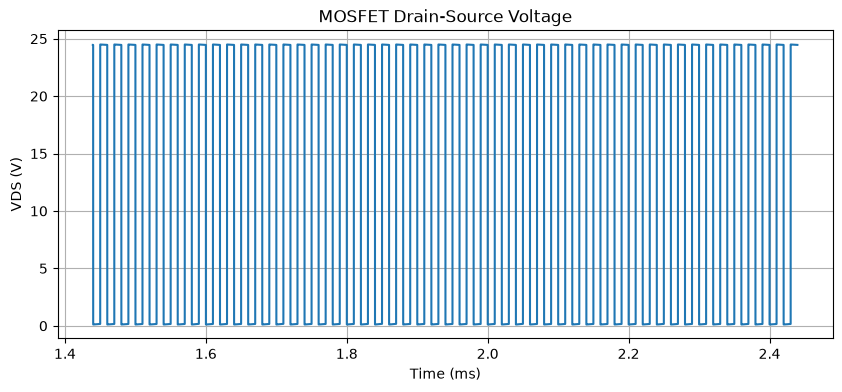

In [14]:
plt.figure(figsize=(10, 4))
plt.plot(time * 1000, vds)
plt.xlabel("Time (ms)")
plt.ylabel("VDS (V)")
plt.title("MOSFET Drain-Source Voltage")
plt.grid()
plt.show()

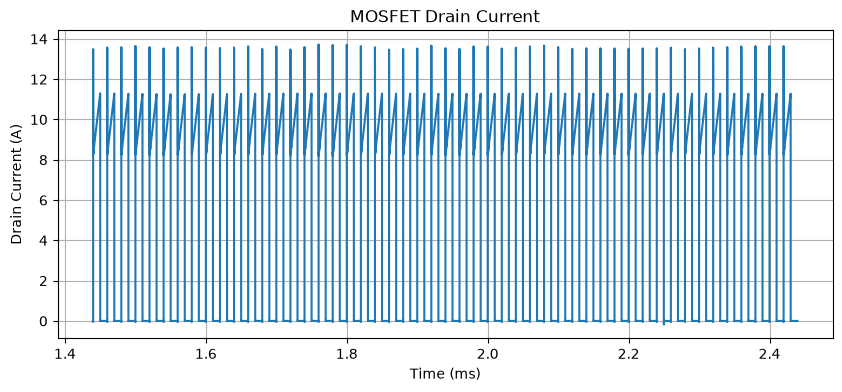

In [15]:
plt.figure(figsize=(10, 4))
plt.plot(time * 1000, ids)
plt.xlabel("Time (ms)")
plt.ylabel("Drain Current (A)")
plt.title("MOSFET Drain Current")
plt.grid()
plt.show()

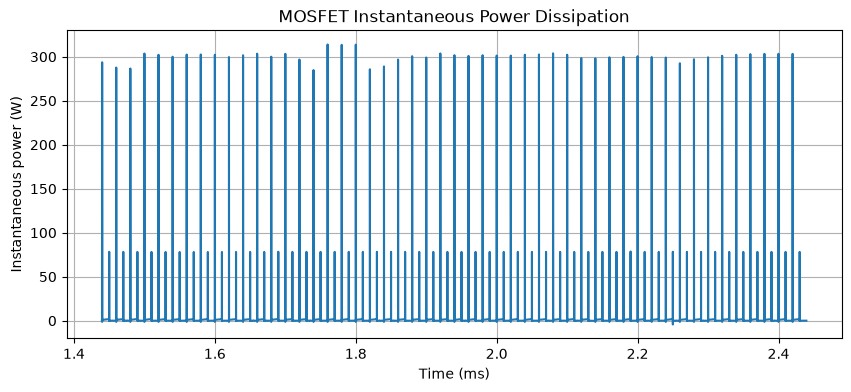

In [13]:
plt.figure(figsize=(10, 4))
plt.plot(time * 1000, power)

plt.xlabel("Time (ms)")
plt.ylabel("Instantaneous power (W)")
plt.title("MOSFET Instantaneous Power Dissipation")
plt.grid()

plt.show()

In [17]:
analytical_power = 1.325
ltspice_power = 0.7308

difference = analytical_power - ltspice_power
percentage_difference = abs(difference) / analytical_power * 100

print(f"Analytical power loss = {analytical_power:.3f} W")
print(f"LTspice average power loss = {ltspice_power:.3f} W")
print(f"Difference = {abs(difference):.3f} W")
print(f"Percentage difference = {percentage_difference:.1f}%")

Analytical power loss = 1.325 W
LTspice average power loss = 0.731 W
Difference = 0.594 W
Percentage difference = 44.8%


## Conclusion

The analytical calculation predicted a total average MOSFET power loss of **1.325 W**, consisting of **0.695 W conduction loss** and **0.630 W switching loss**. The average power calculated from the exported LTspice voltage and current waveforms was **0.7308 W**, which closely agrees with the direct LTspice measurement of approximately **0.7311 W**. This confirms that the waveform export and numerical integration were performed correctly.

The analytical result is approximately **44.8% higher** than the LTspice result. This difference is mainly caused by the simplified assumptions used in the analytical switching-loss equation. The calculation assumes a linear overlap of the drain-source voltage and drain current throughout the full datasheet rise and fall times. These switching times were measured under specific datasheet test conditions and may not exactly represent the operating conditions of the simulated buck converter.

LTspice instead calculates instantaneous device power directly from the simulated \(V_{DS}\) and \(I_D\) waveforms. The ideal gate-voltage source used in the model may also produce faster effective switching transitions, reducing voltage-current overlap and therefore lowering the predicted switching loss.

Therefore, the **0.731 W LTspice result is reasonable for the simulated circuit**, while the **1.325 W analytical result provides a more conservative estimate for engineering and thermal-design purposes**.